# 変数分離法
<!-- colab-link -->
[Google Colab で開く](https://colab.research.google.com/github/aizawan/mathematical-analysis/blob/main/notebooks/differential_equations/separation_of_variables_method.ipynb)



変数分離形とは，微分方程式の関数 $f(x,y)$が$x$と$y$のそれぞれの関数$g(x),h(y)$に分離できるときに利用できる解法である．すなわち，

$$
\begin{align}
\frac{dy}{dx} = g(x)h(y)
\end{align}
$$

に式変形できるときに利用される方法である．変数分離形は常微分方程式の解法の中でも最も基本的で強力な解法の一つであるので，実際に計算し，身につけてほしい．

## 変数分離形の解法
与えられた一階常微分方程式が上記のような形状に式変形可能であるとき，次のステップを踏むことで未知関数 $y=y(x)$ を計算できる．

まず，前述した分離形の微分方程式の両辺に$dx$をかけると以下のようになる

$$
\begin{align}
dy = g(x)h(y)dx
\end{align}
$$

続いて，両辺を$h(y)$で割ると以下のようになる．

$$
\begin{align}
\frac{1}{h(y)}dy = g(x)dx
\end{align}
$$

式を見てわかるように，$x$と$y$の項がそれぞれ両辺に移項できたことがわかる．最後に両辺を積分する．

$$
\begin{align}
\int\frac{1}{h(y)}dy = \int g(x)dx
\end{align}
$$

この積分を実行することで微分方程式の解である未知関数 $y(x)$を求めることができる．

```{admonition} 注意
直接積分形と同様に，変数分離法においても $dx$ でかけるというのは形式的な説明であり，厳密には両辺の不定積分を行うことを意味している．直接積分形から拡張し，具体的に，

$$
\begin{align}
\frac{dy}{dx} = g(x) h(y)
\end{align}
$$

という微分方程式より，$h(y) \neq 0$ として，両辺を$h(y)$ でわると，

$$
\begin{align}
\frac{1}{h(y)} \frac{dy}{dx} = g(x)
\end{align}
$$

が得られる．ここで $y=y(x)$ であるため，$1/h(y)$ は $y(x)$ を通じて $x$ の関数とみなせる．したがって，両辺を $x$ で積分すると，

$$
\begin{align}
\int \left(\frac{1}{h(y)} \frac{dy}{dx}\right) dx &= \int g(x) dx \\
\int \frac{1}{h(y)} dy &= \int g(x) dx \\
H(y) &= \int g(x) dx + C
\end{align}
$$

となる．ただし，$H(y)$ は $1/h(y)$ の原始関数である．
```

```{admonition} $h(y)$ で割るときの注意
式

$$
\frac{1}{h(y)} dy = g(x) dx
$$

を導くために $h(y)$ で両辺を割る操作を行ったが，これは解を考える区間で $h(y(x))\neq 0$ であることを仮定している．もし $h(y_0)=0$ となる値 $y_0$ があれば，定数関数 $y(x)=y_0$ は元の微分方程式の解になる可能性がある．このような解は $h(y)$ で割る操作によって除外されるため，変数分離後に別途確認する必要がある．特に $h(y)$ が恒等的に0である場合，微分方程式は $dy/dx=0$ となり，任意定数 $C$ に対して $y(x)=C$ が解となる．
```

## 変数分離形の具体例
では，次の微分方程式を変数分離形で解いてみよう．以下の微分方程式は $g(x)=1, h(y)=y$のときの場合である．

$$
\begin{align}
\frac{dy}{dx} = y
\end{align}
$$

解答はクリックで確認できる．

````{dropdown} 解答
まず，左辺に $y$ のみ，右辺に $x$ の項のみとなるように整理すると，

$$
\begin{align}
\frac{dy}{y} = dx
\end{align}
$$

となる．続いて，両辺を積分することを考える．

$$
\begin{align}
\int \frac{dy}{y} = \int dx
\end{align}
$$

```{admonition} $1/x$ 型の積分
:class: tip

$1/x$ の積分は $\log |x|$ である．同様に，変数が $y$ の場合は

$$
\int \frac{1}{y}\,dy = \log |y| + C
$$

となる．絶対値が付くのは，$y>0$ の区間でも $y<0$ の区間でも微分すると $1/y$ になる形で原始関数を表すためである．
```

より，積分すると以下となる．

$$
\begin{align}
\log |y| = x + C'
\end{align}
$$


ここで本来ならば，左辺の積分定数 $C_1$ と右辺の積分定数 $C_2$ が存在するがまとめて $C'=C_2 - C_1$ としている．指数関数を用いると，$\log |y| = x + C'$ より $|y| = e^{x+C'}$ である．絶対値を外すと，

$$
\begin{align}
|y| &= e^{x + C'} \\
y &= \pm e^{C'} e^x \\
y & = C e^x
\end{align}
$$

となる．ただし，$C=\pm e^{C'}$ としている．この導出では $y$ で割ったため $y=0$ を一度除外しているが，$y=0$ も元の微分方程式を満たす．したがって $C$ を任意実数としてよく，一般解は $y=C e^x$ と表せる．以上より，与えられた微分方程式を変数分離形で解くことができた．
````

## Pythonによる実装
では，上記の微分方程式をsympyで解く．単一のセルで作成したが，各行での動作は前回の講義のようにStep-by-stepで確認されたい．

In [1]:
from sympy import symbols, Eq, Derivative, Function, dsolve

# 変数と未知関数の定義
x = symbols('x')
y = Function('y')(x)

# dy/dxの定義
dy = Derivative(y, x)

# 微分方程式の定義
eq = Eq(dy, y)

# 微分方程式を解く
y_ = dsolve(eq, y)
y_

Eq(y(x), C1*exp(x))

手計算と結果が一致することを確認されたい．最後に解集合を可視化する．

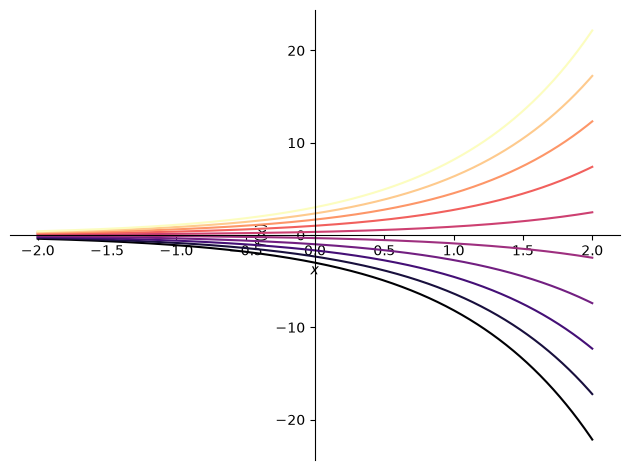

In [2]:
import numpy as np
from sympy import plotting
import matplotlib.pyplot as plt

N = 10

eqs = []
for c in np.linspace(-3, 3, N):
    eqs.append(y_.rhs.subs(symbols('C1'), c))
p = plotting.plot(*eqs, (x, -2, 2), show=False)

cm = plt.get_cmap('magma', N)
for i in range(cm.N):
    p[i].line_color = cm(i)
p.show()


## 置換による変数分離形への帰着
微分方程式によっては置換により変数分離形に帰着できる形がある．具体的に，

$$
\frac{dy}{dx} = f(y + ax + b)
$$

のような微分方程式を考える．このような微分方程式では直接的に変数分離することはできない．

そこで，$u = y + ax + b$ で置換する．このとき

$$
\frac{du}{dx} = \frac{dy}{dx} + a
$$

となる．これを与えられた微分方程式に代入すると

$$
\begin{align}
\frac{du}{dx} - a &= f(u) \\
\frac{du}{dx} &= f(u) + a \\
\end{align}
$$

となり，変数分離形に帰着できる．

そして，

$$
\begin{align}
\frac{1}{f(u) + a} du &= dx \\
\end{align}
$$

となり，両辺を積分すると

$$
\begin{align}
\int \frac{1}{f(u) + a} du &= \int dx \\
\int \frac{1}{f(u) + a} du &= x + C \\
\end{align}
$$

で一般解を導出できる．ただし，$C$は任意定数とする．なお，$f(u)+a=0$ となる定数 $u=u_0$ が存在する場合，$u(x)=u_0$ も解の候補になる．これは $f(u)+a$ で割る操作では除外されるため，別途確認する必要がある．

## 置換による変数分離形の具体例

次の微分方程式を解く．

$$
\frac{dy}{dx} = \frac{1}{y+x} - 1
$$

解答はクリックで確認できる．

````{dropdown} 解答
ここで，$u=y+x$として一般解を求める．

このとき，両辺を $x$ で微分したときの導関数は次のようになる．

$$
\frac{du}{dx} = \frac{dy}{dx} + 1
$$

これを与えられた微分方程式に代入し，変形すると，

$$
\begin{align}
\frac{du}{dx} - 1 &= \frac{1}{u} - 1 \\
\frac{du}{dx}  &= \frac{1}{u}
\end{align}
$$

これを変数分離形として解く．

$$
\begin{align}
\frac{du}{dx} &= \frac{1}{u} \\
u du &= dx
\end{align}
$$

ここで $u=0$ では元の微分方程式の右辺が定義されないため，$u$ をかける操作で解を失うことはない．

両辺を積分し，整理する．

$$
\begin{align}
\int u du  &= \int dx \\
\frac{1}{2} u^2 &= x + C \\
\frac{1}{2} (y+x)^2 &= x + C
\end{align}
$$

これを $y$ について解く．

$$
y = -x \pm \sqrt{2x + 2C}
$$

以上より一般解が得られた．実数解として扱う場合は，平方根の中身が $2x+2C\geq 0$ となる範囲で考える．
````

## Pythonによる実装
では，上記の微分方程式をsympyで解く．

In [3]:
from sympy import symbols, Eq, Derivative, Function, dsolve

# 変数と未知関数の定義
x = symbols('x')
y = Function('y')(x)

# dy/dxの定義
dy = Derivative(y, x)

# 微分方程式の定義
eq = Eq(dy, 1 / (y + x) - 1)

# 微分方程式を解く
y_ = dsolve(eq, y)

このとき手計算した一般解からもわかるように，SymPy は平方根の符号に対応する二つの陽関数表示を返すことに注意する．ここで **陽関数表示** とは，未知関数を $y=\varphi(x)$ のように $x$ の式として明示的に表した形である．一方，$F(x,y)=0$ のように $x$ と $y$ の関係式として表したものを **陰関数表示** という．たとえば，$\frac{1}{2}(y+x)^2=x+C$ は陰関数表示であり，$y=-x\pm\sqrt{2x+2C}$ は陽関数表示である．

In [4]:
y_[0]

Eq(y(x), -x - sqrt(C1 + 2*x))

In [5]:
y_[1]

Eq(y(x), -x + sqrt(C1 + 2*x))

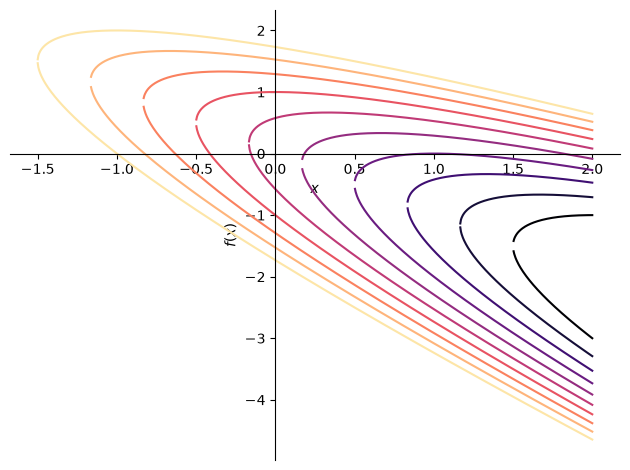

In [6]:
import numpy as np
from sympy import plotting
import matplotlib.pyplot as plt

N = 10

eqs = []
for c in np.linspace(-3, 3, N):
    eqs.append(y_[0].rhs.subs(symbols('C1'), c))
    eqs.append(y_[1].rhs.subs(symbols('C1'), c))
p = plotting.plot(*eqs, (x, -2, 2), show=False)

cm = plt.get_cmap('magma', N*2)
for i in range(0, cm.N, 2):
    p[i].line_color = cm(i)
    p[i+1].line_color = cm(i)
p.show()